In [8]:
pip install rdkit

In [9]:
import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import Descriptors, Lipinski
from rdkit.Chem import Draw, rdFingerprintGenerator
from rdkit.Chem.rdFingerprintGenerator import AdditionalOutput
from IPython.display import Image, display

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# **Part 1:** Introduction to RDkit and molecular descriptors

SMILES format of molecules representation

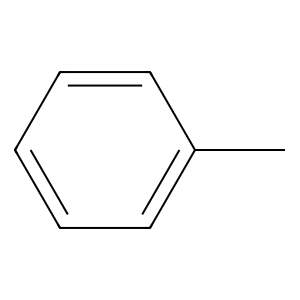

In [10]:
# create molecule object for SMILES string (rdkit.mol)

mol1 = Chem.MolFromSmiles('Cc1ccccc1') # toluene

# visualize molecule with rdkit.Chem.Draw
img = Draw.MolToImage(mol1, size=(300, 300))
display(img)


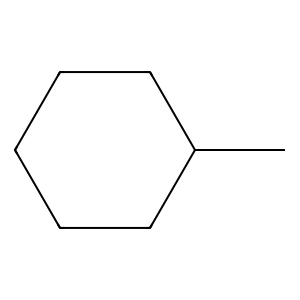

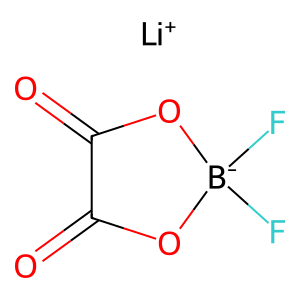

In [11]:
# another molecules

mol2 = Chem.MolFromSmiles('CC1CCCCC1') # big C == aliphatic carbons, small c == aromatic

mol3 = Chem.MolFromSmiles('[Li+].[B-]1(OC(=O)C(=O)O1)(F)F')

img2 = Draw.MolToImage(mol2, size=(300, 300))
display(img2)

img3 = Draw.MolToImage(mol3, size=(300, 300))
display(img3)


In [12]:
# generate SMILES from mol
smiles_from_mol1 = Chem.MolToSmiles(mol1)
print('Canonical SMILES:', smiles_from_mol1)

Canonical SMILES: Cc1ccccc1


In [13]:
# in general, there is no matter in the sequence of atoms - toluene

test_smiles_list = [
    'Cc1ccccc1',
    'CC1=CC=CC=C1',
    'c1ccccc1C'
]

for smi in test_smiles_list:
  mol_test = Chem.MolFromSmiles(smi)
  print(f'Initial SMILES: {smi}')
  print(f'Canonical SMILES: {Chem.MolToSmiles(mol_test)}')
  print('---')


Initial SMILES: Cc1ccccc1
Canonical SMILES: Cc1ccccc1
---
Initial SMILES: CC1=CC=CC=C1
Canonical SMILES: Cc1ccccc1
---
Initial SMILES: c1ccccc1C
Canonical SMILES: Cc1ccccc1
---


Morgan Fingerprints (ECFP)

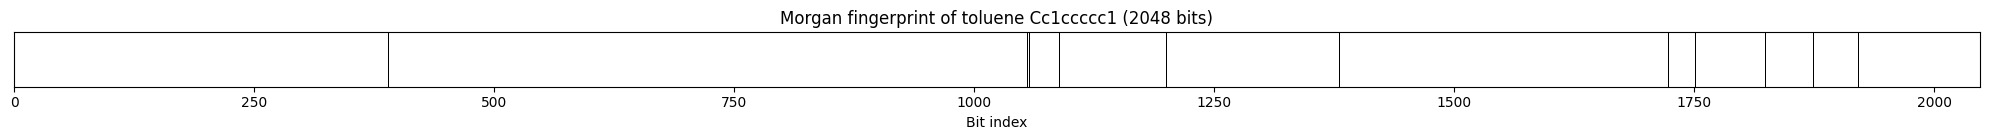

Length fingerprint: 2048 bit
Number of ones: 11
Density: 0.0054


In [15]:
# create Morgan fingerprints generator (radius 2, 2048 bits)
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# toluene from SMILES to mol object
smiles = 'Cc1ccccc1'
mol = Chem.MolFromSmiles(smiles)

# get fingerprint as binary vector
fp = fpgen.GetFingerprint(mol)
fp_array = np.array(fp)  # array of 0 / 1

# Visualize
plt.figure(figsize=(20, 1.5))
plt.imshow(fp_array.reshape(1, -1), cmap='binary', aspect='auto', interpolation='none')
plt.yticks([])
plt.xlabel('Bit index')
plt.title(f'Morgan fingerprint of toluene {smiles} (2048 bits)')
plt.tight_layout()
plt.show()

print(f'Length fingerprint: {len(fp_array)} bit')
print(f'Number of ones: {np.sum(fp_array)}')
print(f'Density: {np.sum(fp_array)/len(fp_array):.4f}')



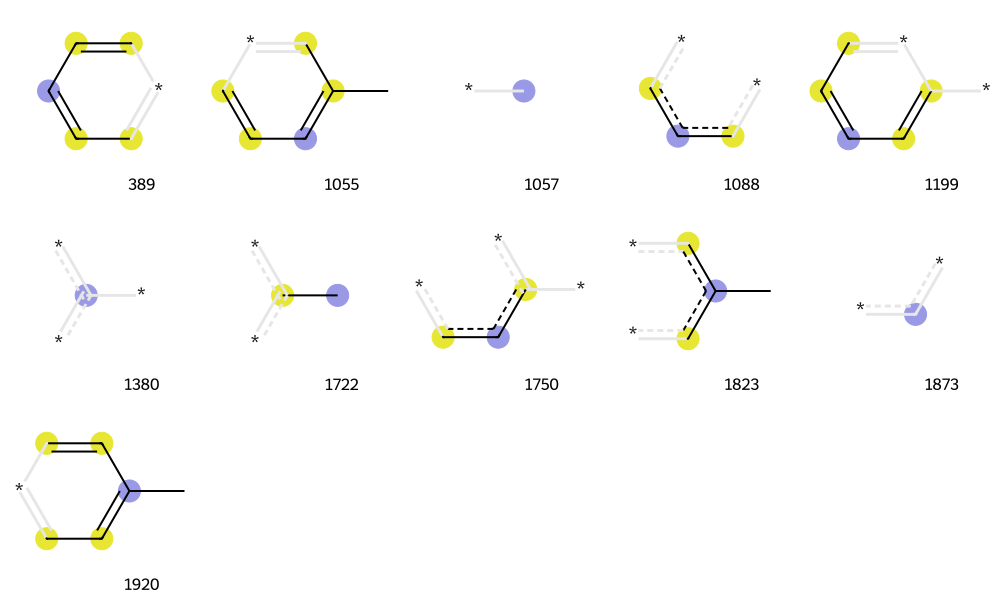

In [16]:
# What fragments correspond the 1 bits? bitInfo
ao = rdFingerprintGenerator.AdditionalOutput()
ao.AllocateBitInfoMap()
fpgen.GetFingerprint(mol, additionalOutput=ao)
bit_info = ao.GetBitInfoMap()

# write bits
bits_to_show = list(bit_info.keys())

# Visualize
draw_data = [(mol, bit, bit_info) for bit in bits_to_show]
legends = [f'Бит {bit}' for bit in bits_to_show]
img = Draw.DrawMorganBits(draw_data, molsPerRow=5, subImgSize=(200,200), legends=legends)
display(img)

Molecular descriptors from SMILES

,molecule,MolWt,MolLogP,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds
0,toluene,92.141,1.99502,0,0,0.00,0
1,LiDFOB,143.767,-3.53500,0,4,52.60,0
2,hexane,86.178,2.58660,0,0,0.00,3
3,ethylene_glycol,62.068,-1.02900,2,2,40.46,1


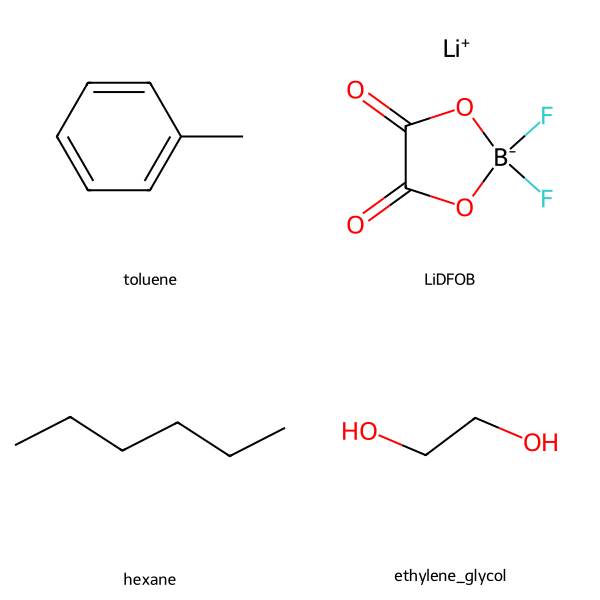

In [17]:
# we will compare the four very different molecules
smiles_list = [
    'Cc1ccccc1',                      # toluene - non-polar, hydrophobic, aromatic
    '[Li+].[B-]1(OC(=O)C(=O)O1)(F)F', # LiDFOB – polar ionic, hydrophilic
    'CCCCCC',                         # hexane - non-polar, hydrophobic, aliphatic
    'OCCO'                            # ethylene glycol - polar, hydrophilic
]
names = ['toluene', 'LiDFOB', 'hexane', 'ethylene_glycol']

# calculate descriptors
def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        'MolWt': Descriptors.MolWt(mol),
        'MolLogP': Descriptors.MolLogP(mol),                      # n-octanol/water partition coefficient
        'NumHDonors': Lipinski.NumHDonors(mol),
        'NumHAcceptors': Lipinski.NumHAcceptors(mol),
        'TPSA': Descriptors.TPSA(mol),                            # Topological Polar Surface Area
        'NumRotatableBonds': Descriptors.NumRotatableBonds(mol)
    }

# get data
data = []
valid_mols = []
valid_names = []
for smi, name in zip(smiles_list, names):
    desc = compute_descriptors(smi)
    desc['molecule'] = name
    data.append(desc)
    valid_mols.append(Chem.MolFromSmiles(smi))
    valid_names.append(name)

# dataframe
df = pd.DataFrame(data)
df = df[['molecule', 'MolWt', 'MolLogP', 'NumHDonors', 'NumHAcceptors', 'TPSA', 'NumRotatableBonds']]
display(df)

# visualize molecules
img = Draw.MolsToGridImage(
    valid_mols,
    molsPerRow=2,
    subImgSize=(300, 300),
    legends=valid_names
)
display(img)

## For more please see RDkit book:
https://www.rdkit.org/docs/RDKit_Book.html#

# **Part 2:** (case study) Hydration energy prediction with RandomForest

$\Delta G(mol)_{hydration} = G(mol)_{aq} - G(mol)_{gas}$

May be measured with calorimetry or calculated with quantum chemistry methods

In [18]:
# load data
url = 'https://raw.githubusercontent.com/mariiasolovieva/intro-molecules_informatics/refs/heads/main/data/freesolv.txt'

In [19]:
# read data

column_names = [
    'compound_id',
    'SMILES',
    'iupac_name',
    'exp_value_kcal_mol',
    'exp_uncertainty_kcal_mol',
    'gaff_calc_value_kcal_mol',
    'calc_uncertainty_kcal_mol',
    'exp_reference',
    'calc_reference',
    'notes'
]

df = pd.read_csv(
    url,
    delimiter=';',
    skiprows=3,
    names=column_names,
    encoding='utf-8'
)

In [ ]:
df.head()

,compound_id,SMILES,iupac_name,exp_value_kcal_mol,exp_uncertainty_kcal_mol,gaff_calc_value_kcal_mol,calc_uncertainty_kcal_mol,exp_reference,calc_reference,notes
0,mobley_1017962,CCCCCC(=O)OC,methyl hexanoate,-2.49,0.6,-3.30,0.03,10.1021/ct050097l,10.1021/acs.jced.7b00104,Experimental uncertainty not presently availa...
1,mobley_1019269,CCCCO,butan-1-ol,-4.72,0.6,-3.23,0.03,10.1021/ct050097l,10.1021/acs.jced.7b00104,Experimental uncertainty not presently availa...
2,mobley_1034539,c1cc(c(cc1c2cc(c(c(c2Cl)Cl)Cl)Cl)Cl)Cl,"1,2,3,4-tetrachloro-5-(3,4-dichlorophenyl)ben...",-3.04,0.1,-1.08,0.04,10.1007/s10822-012-9568-8,10.1021/acs.jced.7b00104,Experimental uncertainty not presently availa...
3,mobley_1036761,C1CCC(CC1)N,cyclohexanamine,-4.59,0.6,-3.95,0.03,10.1021/ct050097l,10.1021/acs.jced.7b00104,Experimental uncertainty not presently availa...
4,mobley_1046331,c1ccc(cc1)OC=O,phenyl formate,-3.82,0.6,-5.44,0.03,"J. Peter Guthrie, unpublished data, as provid...",10.1021/acs.jced.7b00104,Experimental uncertainty not presently availa...


# RandomForest energy prediction

In [24]:
def load_freesolv_data(filepath):
  """Load freesolv.txt data"""

  column_names = [
  'compound_id',
  'SMILES',
  'iupac_name',
  'exp_value_kcal_mol',
  'exp_uncertainty_kcal_mol',
  'gaff_calc_value_kcal_mol',
  'calc_uncertainty_kcal_mol',
  'exp_reference',
  'calc_reference',
  'notes'
  ]

  df = pd.read_csv(
  'freesolv.txt',
  delimiter=';',
  skiprows=3,
  names=column_names,
  encoding='utf-8'
  )

  target_col = 'exp_value_kcal_mol'
  df = df[['SMILES', target_col]].dropna()

  df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
  df = df.dropna()

  print(f'{len(df)} molecules downloaded')

  return df, target_col


def smiles_to_fp(smiles, radius=2, n_bits=2048):
  """Convert SMILES to MorganFingerprints"""

  mol = Chem.MolFromSmiles(smiles)
  if mol is None:
      return None

  fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
  fp = fpgen.GetFingerprint(mol)

  return np.array(fp)


def smiles_to_fp_with_descriptors(smiles, radius=2, n_bits=2048):
  """Convert SMILES to MorganFingerprints and add descriptors"""
  mol = Chem.MolFromSmiles(smiles)
  if mol is None:
      return None

  # Morgan fingerprint
  fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
  fp = fpgen.GetFingerprint(mol)
  fp_array = np.array(fp)

  descriptors = [
      Descriptors.MolWt(mol),             # molecular weight
      Descriptors.MolLogP(mol),           # logP
      Lipinski.NumHDonors(mol),           # number of H donors
      Lipinski.NumHAcceptors(mol),        # number of H acceptors
      Descriptors.TPSA(mol),              # polar area
      Descriptors.NumRotatableBonds(mol), # number of rotational bonds
  ]

  combined = np.concatenate([fp_array, descriptors])
  return combined

def prepare_features(df, smiles_col='SMILES', target_col=None, descriptors=True):
  """Prepare features and target col for training"""

  fingerprints = []
  valid_indices = []

  for idx, smiles in enumerate(df[smiles_col]):
      if descriptors:
        fp = smiles_to_fp_with_descriptors(smiles)
      else:
        fp = smiles_to_fp(smiles)
      if fp is not None:
          fingerprints.append(fp)
          valid_indices.append(idx)

  X = np.array(fingerprints)
  y = df.iloc[valid_indices][target_col].values

  print(f'{len(X)} molecules processed')
  print(f'Features dimention: {X.shape}')

  return X, y


def train_and_evaluate_rf(X, y, test_size=0.2, random_state=42):
  """Train and evaluate RandomForestRegression"""

  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=test_size, random_state=random_state
  )

  rf = RandomForestRegressor(
      n_estimators=100,
      max_depth=20,
      random_state=random_state,
      n_jobs=-1
  )
  rf.fit(X_train, y_train)

  y_pred_train = rf.predict(X_train)
  y_pred_test = rf.predict(X_test)

  metrics = {
      'train_rmse': np.sqrt(mean_squared_error(y_train, y_pred_train)),
      'test_rmse': np.sqrt(mean_squared_error(y_test, y_pred_test)),
      'train_mae': mean_absolute_error(y_train, y_pred_train),
      'test_mae': mean_absolute_error(y_test, y_pred_test),
      'train_r2': r2_score(y_train, y_pred_train),
      'test_r2': r2_score(y_test, y_pred_test)
  }

  print('\n' + '='*50)
  print('RANDOM FOREST RESULTS')
  print('='*50)
  print(f'Train RMSE: {metrics['train_rmse']:.4f} kcal/mol')
  print(f'Test RMSE:  {metrics['test_rmse']:.4f} kcal/mol')

  plt.figure(figsize=(8, 6))
  plt.scatter(y_test, y_pred_test, color='blue', alpha=0.6)
  plt.plot([y.min(), y.max()], [y.min(), y.max()], 'b--', lw=2)
  plt.xlabel('Experimental values (kcal/mol)')
  plt.ylabel('Predicted values (kcal/mol)')
  plt.title(f'Random Forest with Morgan fingerprints\nRMSE = {metrics['test_rmse']:.3f} kcal/mol')
  plt.tight_layout()
  plt.show()

  return rf, metrics

642 molecules downloaded
642 molecules processed
Features dimention: (642, 2048)

RANDOM FOREST RESULTS
Train RMSE: 0.8264 kcal/mol
Test RMSE:  2.2960 kcal/mol


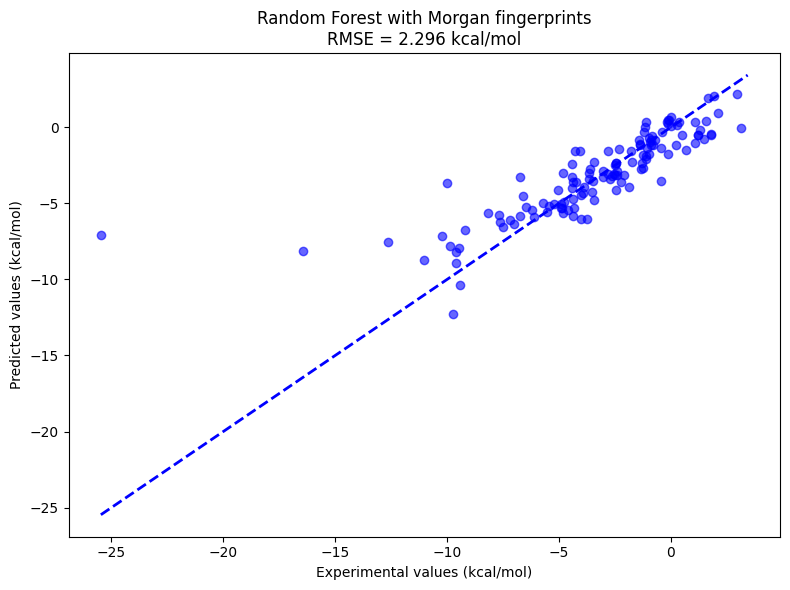

In [22]:
# train only on MorganFingerprints (set descriptors=False in prepare_features())

def main_rf():

    filepath = 'freesolv.txt'
    df, target_col = load_freesolv_data(filepath)
    X, y = prepare_features(df, target_col=target_col)

    model, metrics = train_and_evaluate_rf(X, y)

    return model, metrics

if __name__ == '__main__':
    rf1, metrics1 = main_rf()

642 molecules downloaded

Descriptive statistics:


,MolWt,MolLogP,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds,exp_value
count,642.000000,642.000000,642.000000,642.00000,642.000000,642.000000,642.000000
mean,138.950840,1.933384,0.344237,1.28972,20.403115,1.627726,-3.803006
std,72.700795,1.492977,0.628153,1.41978,22.635754,1.972520,3.847820
min,16.043000,-3.585400,0.000000,0.00000,0.000000,0.000000,-25.470000
25%,94.121500,1.155975,0.000000,0.00000,0.000000,0.000000,-5.727500
50%,120.881000,1.778150,0.000000,1.00000,17.070000,1.000000,-3.530000
75%,159.698000,2.579000,1.000000,2.00000,26.300000,3.000000,-1.215000
max,498.662000,9.887600,6.000000,8.00000,123.660000,12.000000,3.430000


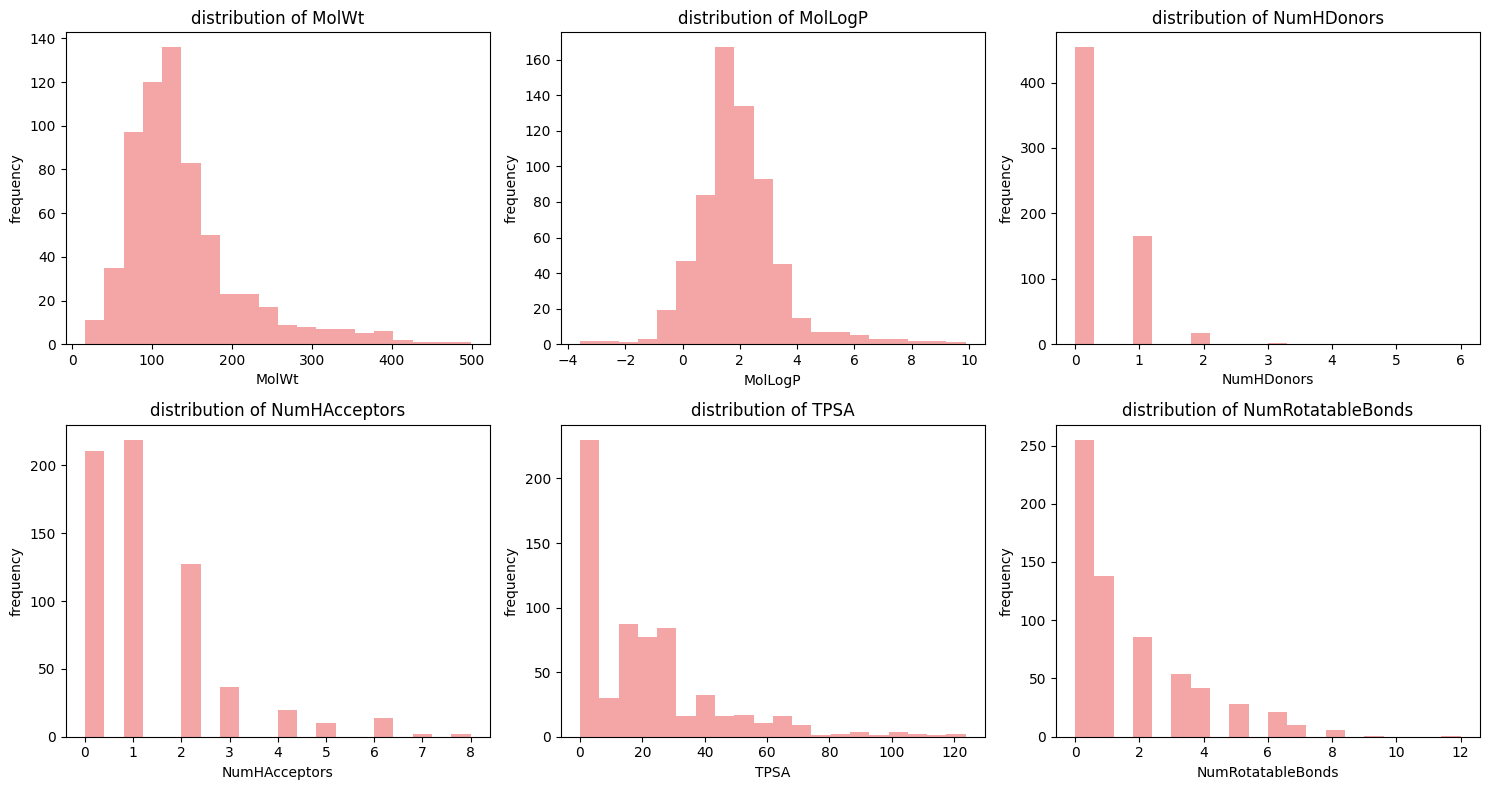

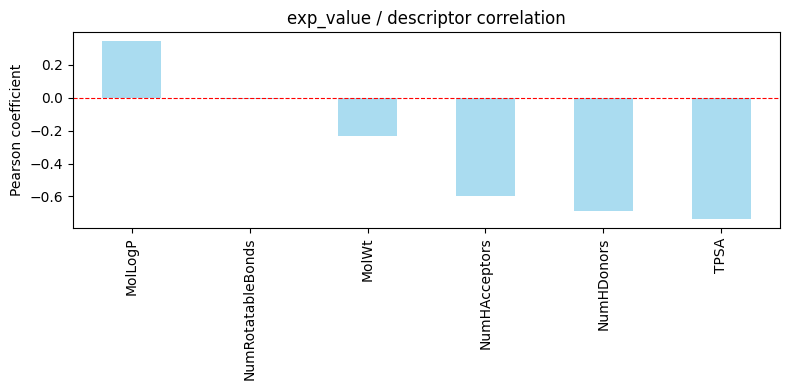

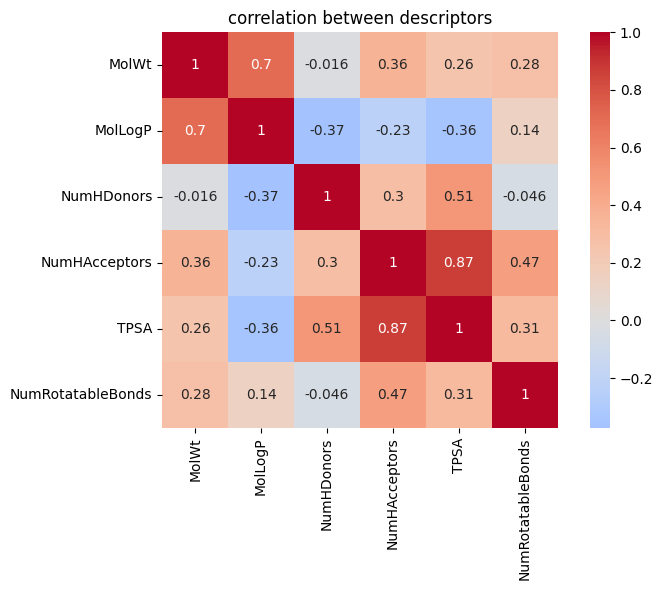

In [23]:
# check descriptor values distribution

from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

filepath = 'freesolv.txt'
df, target_col = load_freesolv_data(filepath)

# calculate descriptor values
def compute_descriptors_for_mol(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        'MolWt': Descriptors.MolWt(mol),
        'MolLogP': Descriptors.MolLogP(mol),
        'NumHDonors': Lipinski.NumHDonors(mol),
        'NumHAcceptors': Lipinski.NumHAcceptors(mol),
        'TPSA': Descriptors.TPSA(mol),
        'NumRotatableBonds': Descriptors.NumRotatableBonds(mol)
    }

# get descriptors for all molecules in the dataframe
desc_list = []
valid_indices = []
for idx, row in df.iterrows():
    desc = compute_descriptors_for_mol(row['SMILES'])
    if desc is not None:
        desc['exp_value'] = row[target_col]
        desc_list.append(desc)
        valid_indices.append(idx)

desc_df = pd.DataFrame(desc_list)


print("\nDescriptive statistics:")
display(desc_df.describe())

# visualize
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

descriptor_names = ['MolWt', 'MolLogP', 'NumHDonors', 'NumHAcceptors', 'TPSA', 'NumRotatableBonds']
for i, name in enumerate(descriptor_names):
    axes[i].hist(desc_df[name], bins=20, color='lightcoral', alpha=0.7)
    axes[i].set_xlabel(name)
    axes[i].set_ylabel('frequency')
    axes[i].set_title(f'distribution of {name}')

plt.tight_layout()
plt.show()

corr_with_target = desc_df.corr()['exp_value'].drop('exp_value').sort_values(ascending=False)

plt.figure(figsize=(8, 4))
corr_with_target.plot(kind='bar', color='skyblue', alpha=0.7)
plt.title('exp_value / descriptor correlation')
plt.ylabel('Pearson coefficient')
plt.axhline(y=0, color='red', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 6))
corr_matrix = desc_df[descriptor_names].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('correlation between descriptors')
plt.tight_layout()
plt.show()

642 molecules downloaded
642 molecules processed
Features dimention: (642, 2054)

RANDOM FOREST RESULTS
Train RMSE: 0.4643 kcal/mol
Test RMSE:  1.2649 kcal/mol


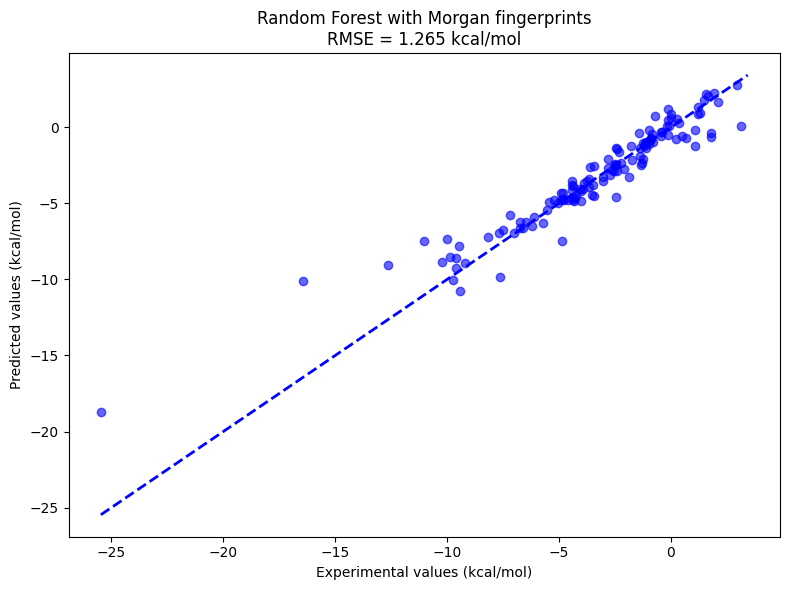

In [25]:
# train using both MorganFingerprints and moleccular descriptors

def main_rf():

    filepath = 'freesolv.txt'
    df, target_col = load_freesolv_data(filepath)
    X, y = prepare_features(df, target_col=target_col)

    model, metrics = train_and_evaluate_rf(X, y)

    return model, metrics

if __name__ == '__main__':
    rf2, metrics2 = main_rf()

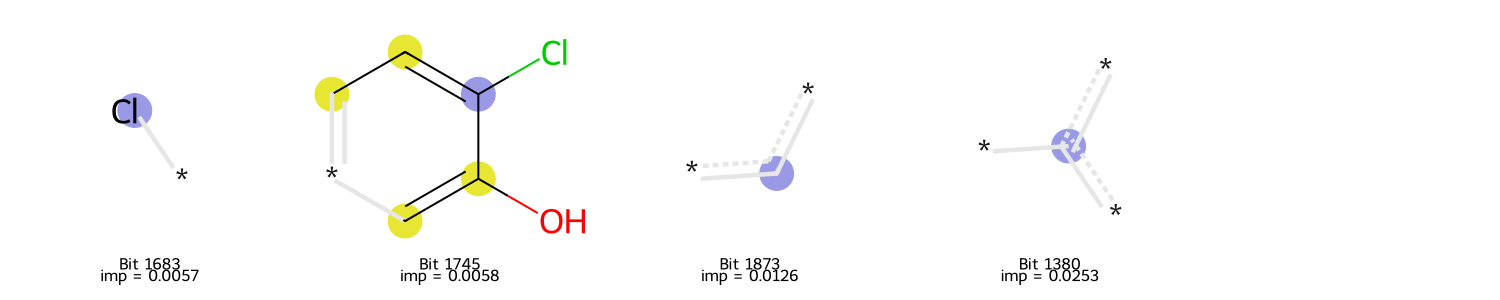


Important additional descriptors:
  NumRotatableBonds (index 2053): importance = 0.0080
  NumHAcceptors (index 2051): importance = 0.0172
  MolWt (index 2048): importance = 0.0230
  MolLogP (index 2049): importance = 0.0385
  NumHDonors (index 2050): importance = 0.1560
  TPSA (index 2052): importance = 0.5814


In [26]:
NBITS = 2048   # fingerprint size
RADIUS = 2

fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=RADIUS, fpSize=NBITS)

def get_bitinfo_for_mol(mol):
    ao = AdditionalOutput()
    ao.AllocateBitInfoMap()
    fpgen.GetFingerprint(mol, additionalOutput=ao)
    return ao.GetBitInfoMap()

def find_molecules_with_bit(df, bit, max_mols=1):
    results = []
    for smiles in df['SMILES'].values:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            continue
        bi = get_bitinfo_for_mol(mol)
        if bit in bi:
            results.append((mol, bi))
            if len(results) >= max_mols:
                break
    return results


descriptor_names = [
    'MolWt', 'MolLogP', 'NumHDonors', 'NumHAcceptors', 'TPSA', 'NumRotatableBonds'
]


top_indices = np.argsort(rf2.feature_importances_)[-10:]

bit_indices = [idx for idx in top_indices if idx < NBITS]
descriptor_indices = [idx for idx in top_indices if idx >= NBITS]

# Draw bits
if bit_indices:
    draw_data = []
    legends = []
    for bit in bit_indices:
        mols_info = find_molecules_with_bit(df, bit, max_mols=1)
        if mols_info:
            mol, bi = mols_info[0]
            draw_data.append((mol, bit, bi))
            importance = rf2.feature_importances_[bit]
            legends.append(f'Bit {bit}\nimp = {importance:.4f}')
        else:
            print(f'Bit {bit} not found')

    if draw_data:
        img = Draw.DrawMorganBits(
            draw_data,
            molsPerRow=5,
            subImgSize=(300, 300),
            legends=legends,
            useSVG=False
        )
        try:
            from IPython.display import display
            display(img)
        except:
            img.save('important_bits.png', dpi=300)
            plt.imshow(img)
            plt.axis('off')
            plt.show()
    else:
        print('No bits to visualize')
else:
    print('Among top-10 no fingerprints found (only descriptors)')


if descriptor_indices:
    print('\nImportant additional descriptors:')
    for idx in descriptor_indices:
        desc_idx = idx - NBITS
        if desc_idx < len(descriptor_names):
            name = descriptor_names[desc_idx]
        else:
            name = f'descriptor_{desc_idx}'
        print(f'  {name} (index {idx}): importance = {rf2.feature_importances_[idx]:.4f}')

**References**
1. Introduction to chemoinformatics by A. Leach, V. Gillet https://doi.org/10.1007/978-1-4020-6291-9

2. GitHub repo FreeSolv: https://github.com/MobleyLab/FreeSolv

*Original paper:* Mobley, D.L., Guthrie, J.P. 'FreeSolv: a database of experimental and calculated hydration free energies, with input files' J Comput Aided Mol Des 28, 711–720 (2014) https://link.springer.com/article/10.1007/s10822-014-9747-x

3. Wu, Zhenqin, et al. 'MoleculeNet: a benchmark for molecular machine learning.' Chemical Science 9.2 (2018): 513-530 https://pubs.rsc.org/en/content/articlelanding/2018/sc/c7sc02664a